# Atividade 5 — Gráficos das atividades 2, 3 e 4



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

## Atividade 2 — Horas de afazeres domésticos

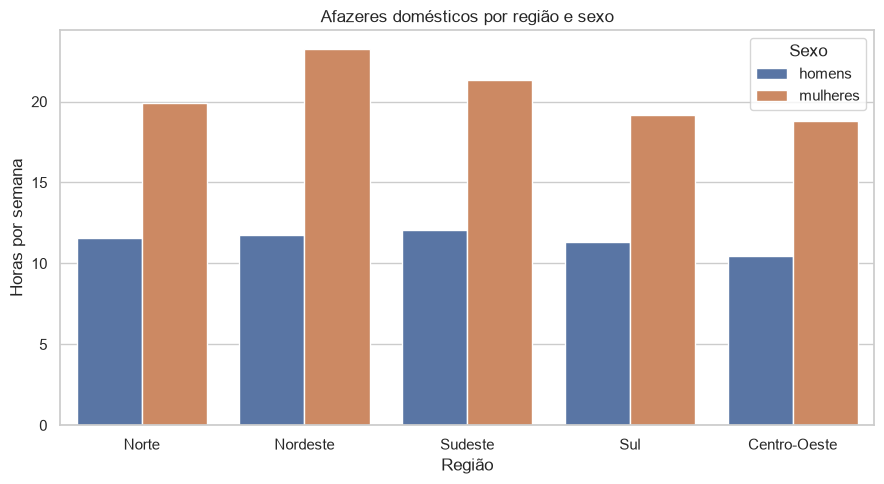

In [2]:
arquivo_atividade_2 = Path("..") / "Atividade2" / "dados_ibge" / "Tabela 1.1.1.xls"
bruto = pd.read_excel(arquivo_atividade_2, engine="xlrd", header=None)

indicador_1 = bruto.iloc[8:41].copy()
indicador_1.columns = [
    "uf_regiao", "total", "total_branca", "total_preta_parda",
    "homem_branca", "homem_preta_parda",
    "mulher_branca", "mulher_preta_parda",
]
for coluna in indicador_1.columns[1:]:
    indicador_1[coluna] = pd.to_numeric(indicador_1[coluna], errors="coerce")

regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]
reg = indicador_1[indicador_1["uf_regiao"].isin(regioes)].copy()
reg["homens"] = reg[["homem_branca", "homem_preta_parda"]].mean(axis=1)
reg["mulheres"] = reg[["mulher_branca", "mulher_preta_parda"]].mean(axis=1)

reg_long = reg.melt(
    id_vars="uf_regiao",
    value_vars=["homens", "mulheres"],
    var_name="sexo",
    value_name="horas",
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=reg_long, x="uf_regiao", y="horas", hue="sexo", ax=ax)
ax.set_title("Afazeres domésticos por região e sexo")
ax.set_xlabel("Região")
ax.set_ylabel("Horas por semana")
ax.legend(title="Sexo")
plt.tight_layout()
plt.show()

## Atividade 3 — Formação acadêmica

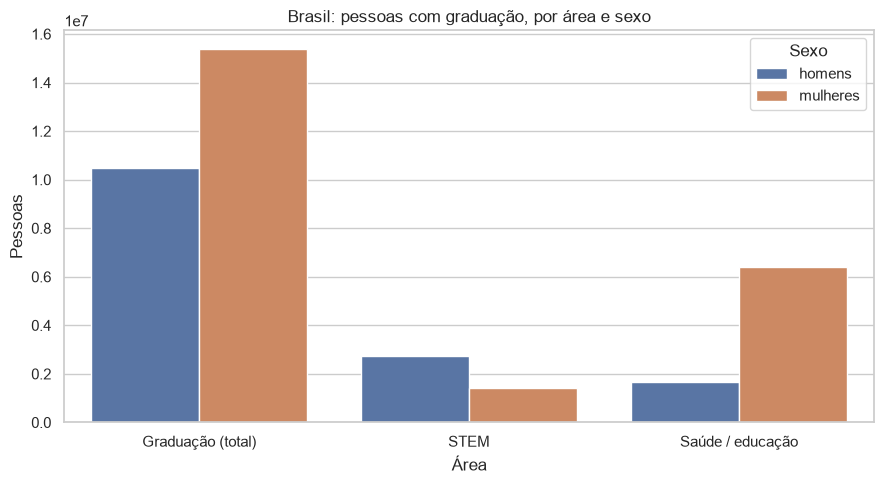

In [3]:
arquivo_atividade_3 = Path("..") / "Atividade3" / "Tabela_3_Areas_gerais_de_formacao_na_graduacao.xlsx"
dados_formacao = pd.read_excel(arquivo_atividade_3, header=None)
 
linha_brasil = dados_formacao[dados_formacao.iloc[:, 0].astype(str).str.strip() == "Brasil"].iloc[0]
brasil = pd.DataFrame({
    "area": ["Graduação (total)", "STEM", "Saúde / educação"],
    "homens": pd.to_numeric([linha_brasil.iloc[2], linha_brasil.iloc[5], linha_brasil.iloc[8]]),
    "mulheres": pd.to_numeric([linha_brasil.iloc[3], linha_brasil.iloc[6], linha_brasil.iloc[9]]),
})

brasil_long = brasil.melt(id_vars="area", var_name="sexo", value_name="pessoas")

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=brasil_long, x="area", y="pessoas", hue="sexo", ax=ax)
ax.set_title("Brasil: pessoas com graduação, por área e sexo")
ax.set_xlabel("Área")
ax.set_ylabel("Pessoas")
ax.legend(title="Sexo")
plt.tight_layout()
plt.show()

## Atividade 4 — População por UF

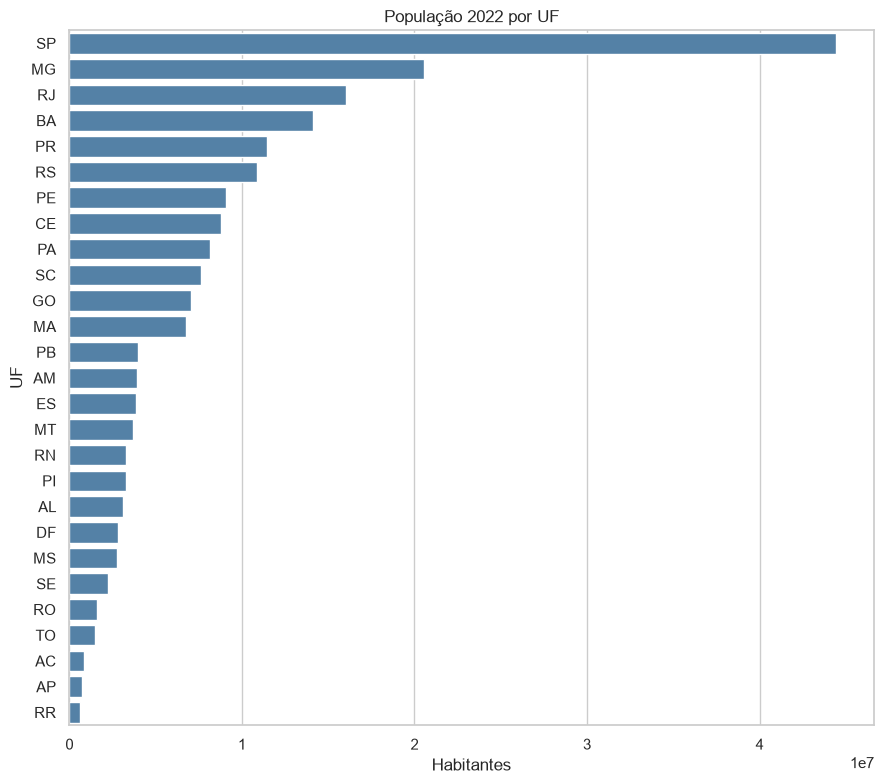

In [4]:
arquivo_atividade_4 = Path("..") / "Atividade4" / "populacao_por_estado.csv"
pop_estado = pd.read_csv(arquivo_atividade_4, sep=";", encoding="utf-8-sig")

coluna_2022 = next(coluna for coluna in pop_estado.columns if "2022" in coluna)
ordem = pop_estado.sort_values(coluna_2022, ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(data=ordem, y="UF", x=coluna_2022, ax=ax, color="steelblue")
ax.set_title("População 2022 por UF")
ax.set_xlabel("Habitantes")
ax.set_ylabel("UF")
plt.tight_layout()
plt.show()